# Text Classification with Random Forest and Gaussian Naive Bayes on IMDB Dataset


## Importing Libraries


In [ ]:
# Import all required libraries
import pandas as pd
import kagglehub
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
nltk.download('stopwords')

## Loading Dataset


In [ ]:
dataset_path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
csv_file_path = f'{dataset_path}/IMDB Dataset.csv'

print(f"Dataset downloaded to: {dataset_path}")
print(f"CSV file path: {csv_file_path}")

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset downloaded to: /kaggle/input/imdb-dataset-of-50k-movie-reviews
CSV file path: /kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


## Preprocessing the Dataset


In [44]:
df = pd.read_csv(csv_file_path)

In [45]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [46]:
df.isnull().sum()

,0
review,0
sentiment,0


In [47]:
df.duplicated().sum()

np.int64(418)

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
df['review'] = df['review'].apply(lambda x:x.lower())

In [50]:
df['review']

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."
...,...
49995,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...


### Removing HTML Tags


In [ ]:
df['review'] = df['review'].apply(lambda x:BeautifulSoup(x,'html.parser').get_text())

In [52]:
df['review']

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming tec...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."
...,...
49995,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...


### Removing Stop Words


In [ ]:
stop_words = stopwords.words('english')
def remove_stopwords(text):
    words = text.split()
    meaningful_words = [w for w in words if w not in stop_words]
    return ' '.join(meaningful_words)

In [56]:
df['review'] = df['review'].apply(remove_stopwords)

### Defining Features and Labels


In [57]:
X = df['review']
y = df['sentiment']

### Splitting the Dataset into Training and Testing Sets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X[:10000], y[:10000], test_size=0.2, random_state=42)

### Applyig Label Encoding on Labels


In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### Vectorizing Text Data Using CountVectorizer


In [ ]:
cv = CountVectorizer()
X_train = cv.fit_transform(X_train).toarray()
X_test = cv.transform(X_test).toarray()

In [61]:
X_train.shape

(8000, 48384)

## Model Training and Evaluation


### Gaussian Naive Bayes Classifier


In [ ]:
model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)

GaussianNB()

### Predictions on Test Set


In [63]:
y_pred_gnb = model_gnb.predict(X_test)

### Confusion Matrix and Accuracy Score


In [ ]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Gaussian Naive Bayes Accuracy: {acc_gnb*100}")

Gaussian Naive Bayes Accuracy: 62.949999999999996


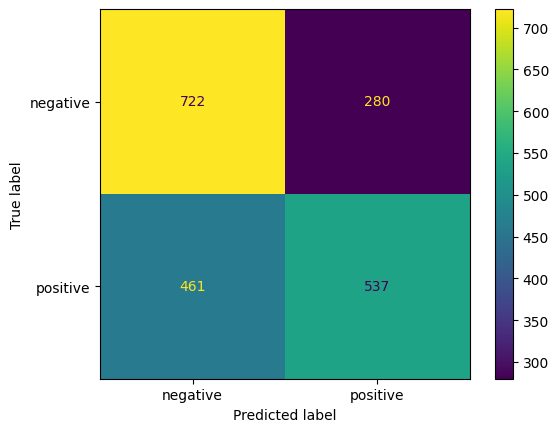

In [65]:
ConfusionMatrixDisplay(cm_gnb, display_labels=le.classes_).plot()

### Random Forest Classifier


In [ ]:
model_rfc = RandomForestClassifier(n_estimators=100, random_state=42)
model_rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Predicting and Evaluating the Model


In [67]:
y_pred_rfc = model_rfc.predict(X_test)
acc_rfc = accuracy_score(y_test, y_pred_rfc)
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
print(f"Random Forest Classifier Accuracy: {acc_rfc*100}")

Random Forest Classifier Accuracy: 84.95


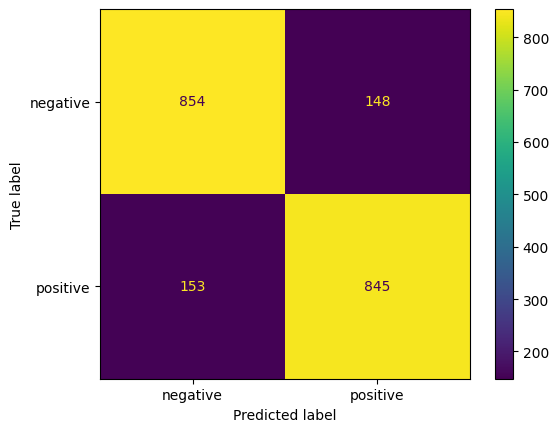

In [68]:
ConfusionMatrixDisplay(cm_rfc, display_labels=le.classes_).plot()

### Applying TF-IDF Vectorization


In [ ]:
# Reset and recreate train/test split
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X[:10000], y[:10000], test_size=0.2, random_state=42)

# Now apply TfidfVectorizer
tfidf = TfidfVectorizer(max_features=10000)
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

### Gaussian Naive Bayes Classifier with TF-IDF Training and Evaluation


In [70]:
model_gnb = GaussianNB()
model_gnb.fit(X_train.toarray(), y_train)
y_pred_gnb = model_gnb.predict(X_test.toarray())
acc_gnb = accuracy_score(y_test, y_pred_gnb)
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
print(f"Gaussian Naive Bayes Accuracy: {acc_gnb*100}")

Gaussian Naive Bayes Accuracy: 72.15


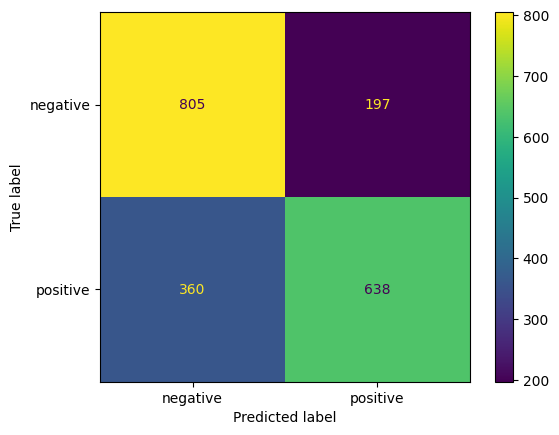

In [71]:
ConfusionMatrixDisplay(cm_gnb, display_labels=le.classes_).plot()

### Random Forest Classifier with TF-IDF Training and Evaluation


In [72]:
model_rfc_tfidf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rfc_tfidf.fit(X_train, y_train)
y_pred_rfc_tfidf = model_rfc_tfidf.predict(X_test)
acc_rfc_tfidf = accuracy_score(y_test, y_pred_rfc_tfidf
)
cm_rfc_tfidf = confusion_matrix(y_test, y_pred_rfc_tfidf)
print(f"Random Forest Classifier with TF-IDF Accuracy: {acc_rfc_tfidf*100:.2f}%")

Random Forest Classifier with TF-IDF Accuracy: 84.55%


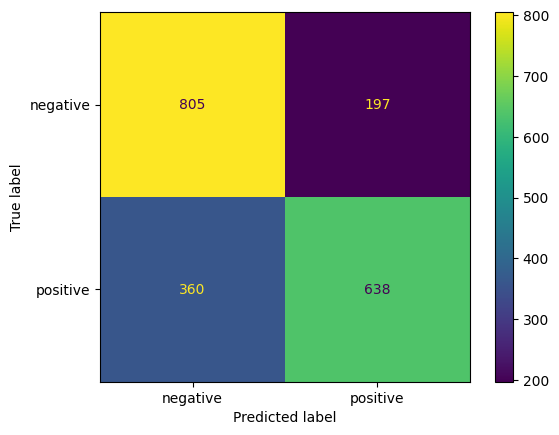

In [73]:
ConfusionMatrixDisplay(cm_gnb, display_labels=le.classes_).plot()